## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score, recall_score
)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

## Data loading

In [ ]:
df_churn = pd.read_csv(r'https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/04-Binary-Classification/bank_churn_modelling.csv?utm_source=chatgpt.com')
df_churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Inspection

In [ ]:
df_churn.shape

(10000, 13)

In [ ]:
df_churn.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'Num Of Products', 'Has Credit Card',
       'Is Active Member', 'Estimated Salary', 'Churn'],
      dtype='object')

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num Of Products   10000 non-null  int64  
 9   Has Credit Card   10000 non-null  int64  
 10  Is Active Member  10000 non-null  int64  
 11  Estimated Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [ ]:
df_churn.duplicated().sum()

np.int64(0)

**Observation:**
All columns have correct datatypes and there is not null value in any of the column. There is no duplicate record in dataset as well.

## Preprocessing for EDA

#### **Rename Column Names**

In [ ]:
df_churn.columns = df_churn.columns.str.replace(' ', '_').str.strip()

In [ ]:
df_churn.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'Num_Of_Products', 'Has_Credit_Card',
       'Is_Active_Member', 'Estimated_Salary', 'Churn'],
      dtype='object')

#### **Drop Irrelevent Columns**

In [ ]:
df_churn.drop(columns=['CustomerId', 'Surname'], axis=1, inplace=True)
df_churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis

In [ ]:
# Statistical Summary of numerical variables
df_churn.describe()

,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Observation:**

The average age of customers is approx 38-39. Where the min age is 18 and oldest age is 92 years. Majority of customers are within range from 32-44 years.

About 75% of the customers have not churn (Value 0) while 25% (value 1)


In [ ]:
# Statistical Summary of categorical values
df_churn.describe(include="object")

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


#### **Univariate Analysis**

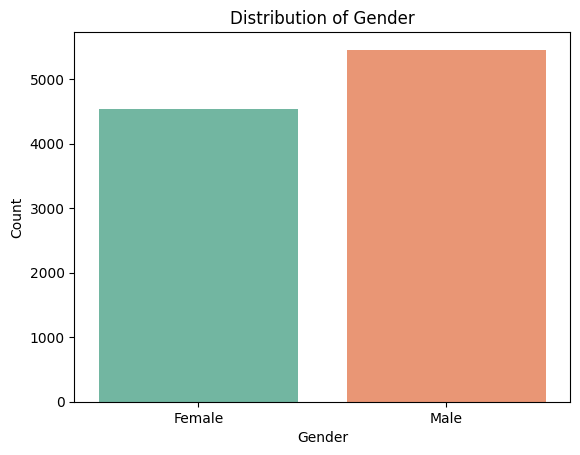

In [ ]:
# Gender distribution
sns.countplot(data=df_churn,
              x='Gender',
              hue='Gender',
              palette='Set2',
              legend=False)

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.show()

**Observation:**

The dataset includes information of two unique genders, where the frequency of females in the dataset is greater than male.

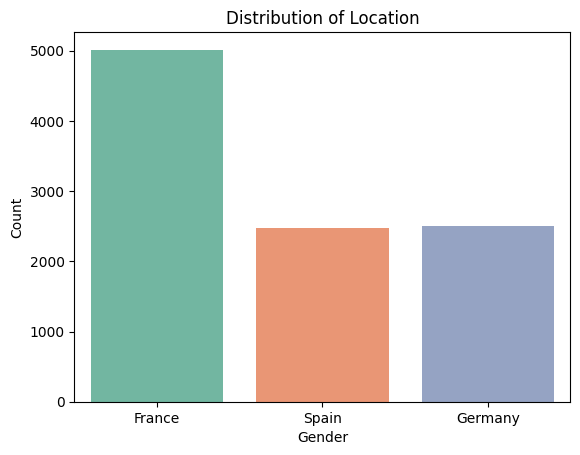

In [ ]:
# Location distribution
sns.countplot(data=df_churn,
              x='Geography',
              hue='Geography',
              palette='Set2',
              legend=False)

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Location')
plt.show()

**Observation:**

The dataset includes information of 3 unique countries including France, Germany and Spain. The most frequency location is France.

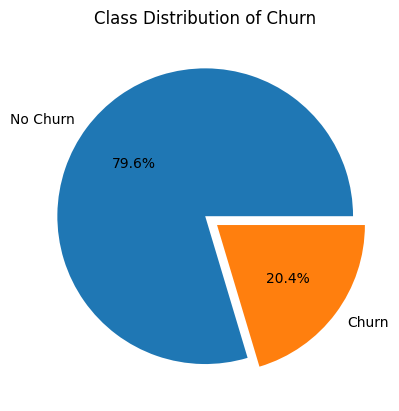

In [ ]:
# Analyze churn distribution
churn_counts = df_churn['Churn'].value_counts()

labels = ['No Churn', 'Churn']

plt.pie(
    churn_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    explode=(0, 0.1)
)
plt.title('Class Distribution of Churn')
plt.show()

**Observation:** The dataset is imbalnced, with approximately 79.6% non-churn customers (7963) and 20.4% churn customers (2037). This imbalance can affect model performance, so techniques like SMOTE are needed to improve the detection of churn cases.

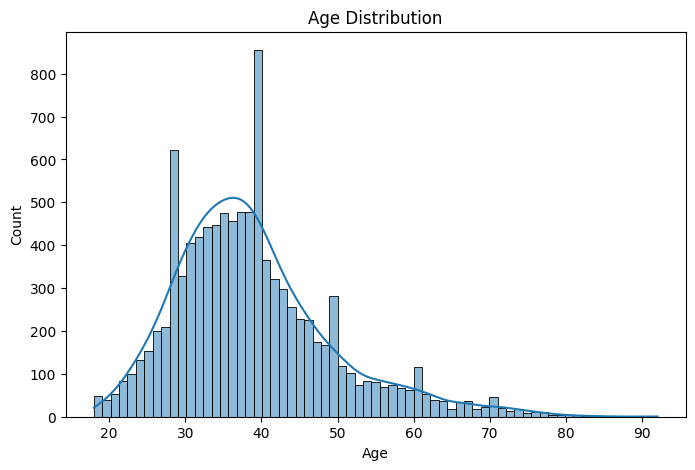

In [ ]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df_churn['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

#### **Bivariate & Multivariate Analysis**

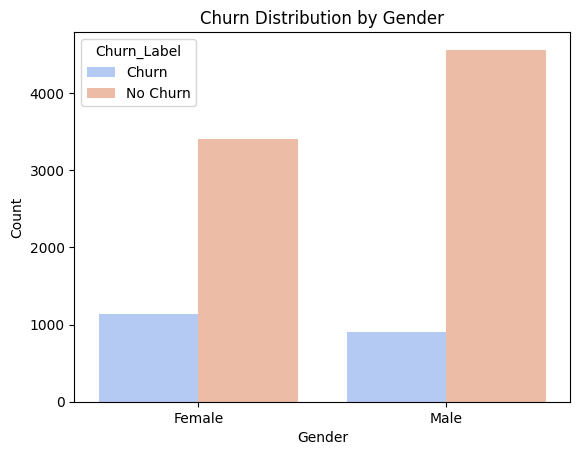

In [ ]:
# Churn Distribution by Gender
df_churn['Churn_Label'] = df_churn['Churn'].map({0: 'No Churn', 1: 'Churn'})

sns.countplot( data=df_churn,
              x='Gender',
              hue='Churn_Label',
              palette = 'coolwarm')

plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

**Observation:** The visualization shows that churn is almost similar for both males and females. In both groups, most customers have not churned, and only a small number of customers have churned. This means gender is not a strong factor in deciding whether a customer will leave or stay.

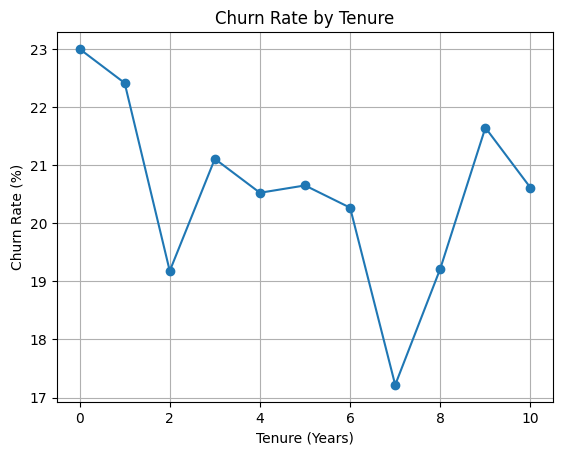

In [ ]:
# Churn Rate by Tenure
tenure_churn = df_churn.groupby('Tenure')['Churn'].mean() * 100

tenure_churn.plot(marker='o')
plt.title("Churn Rate by Tenure")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure (Years)")
plt.grid()
plt.show()

**Observation:** Churn rate is significantly higher among customers with low tenure, indicating that early-stage retention is critical. As tenure increases, customers tend to become more stable, suggesting that long-term engagement strategies are effective in reducing churn.

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Churn, dtype: float64


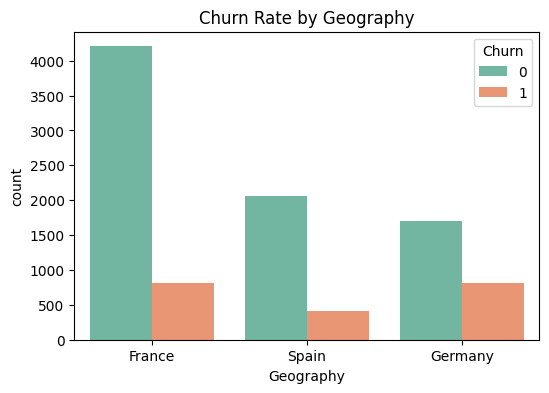

In [ ]:
#Geography Impact on Churn
geo_churn = df_churn.groupby('Geography')['Churn'].mean() * 100
print(geo_churn)

plt.figure(figsize=(6,4))
sns.countplot(data=df_churn,
              x='Geography',
              hue='Churn',
              palette='Set2'
              )
plt.title("Churn Rate by Geography")
plt.show()

**Obseravation: ** Customers in Germany exhibit a significantly higher churn rate (32%) compared to France and Spain (16%), indicating a region-specific retention issue. This suggests that geographic location plays a critical role in customer behavior, and targeted retention strategies should be implemented for the German market.

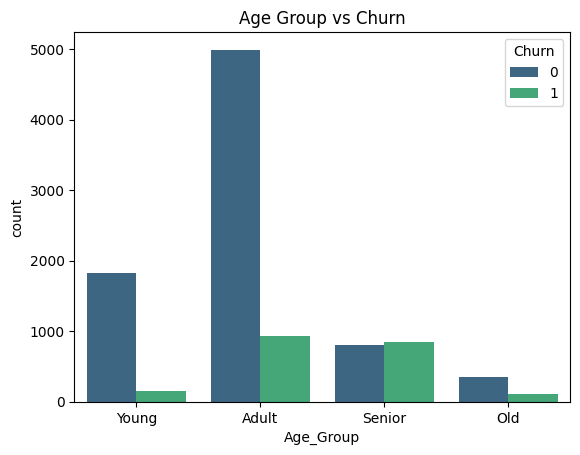

/tmp/ipykernel_67064/3678079039.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_churn.groupby('Age_Group')['Churn'].mean() * 100


,Churn
Age_Group,
Young,7.520325
Adult,15.740584
Senior,51.123254
Old,24.784483


In [ ]:
# Age group and vs churn
df_churn['Age_Group'] = pd.cut(df_churn['Age'],
                               bins=[0,30,45,60,100],
                               labels=['Young','Adult','Senior','Old'])

sns.countplot(data=df_churn,
              x='Age_Group',
              hue='Churn',
              palette='viridis')

plt.title("Age Group vs Churn")
plt.show()

df_churn.groupby('Age_Group')['Churn'].mean() * 100

/tmp/ipykernel_67064/2533507973.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Is_Active_Member
0    26.850897
1    14.269074
Name: Churn, dtype: float64


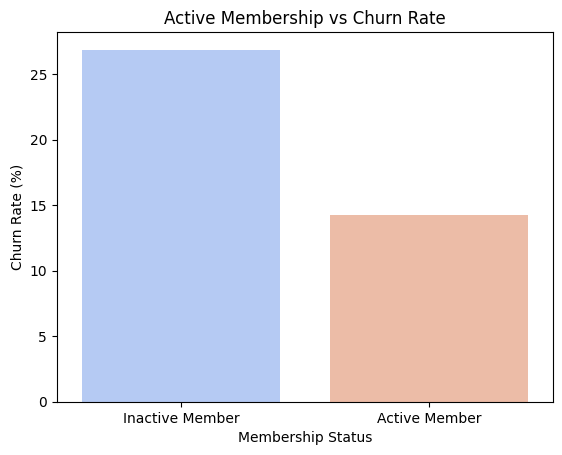

In [ ]:
# Active Member vs Churn
active = df_churn.groupby('Is_Active_Member')['Churn'].mean() * 100
print(active)


active.index = active.index.map({0: 'Inactive Member', 1: 'Active Member'})

sns.barplot(
    x=active.index,
    y=active.values,
    palette='coolwarm'
)

plt.title("Active Membership vs Churn Rate")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Membership Status")
plt.show()

**Obsevation:**
Inactive members show significantly higher churn rate compared to active members, indicating engagement level is a strong predictor of customer retention

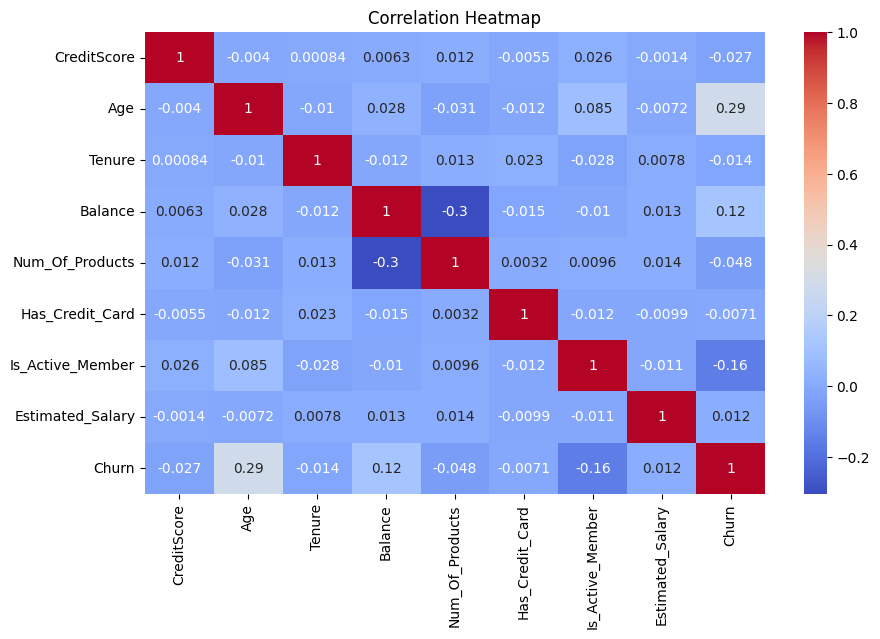

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_churn.select_dtypes(include='number').corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Preprocessing for Modeling

In [ ]:
df_churn.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'Num_Of_Products', 'Has_Credit_Card', 'Is_Active_Member',
       'Estimated_Salary', 'Churn', 'Churn_Label', 'Age_Group'],
      dtype='object')

In [ ]:
# drop unnecessary columns that are created while EDA process
df_churn = df_churn.drop(['Churn_Label', 'Age_Group'], axis=1)

#### **Encode Categorical Variables**

In [ ]:
# one-hot encoding to encode categorical features
df_churn = pd.get_dummies(df_churn, columns=['Geography', 'Gender'], drop_first=True)

Chose One-Hot Encoding as it creates separate binary columns for each category. It is better for nominal data, especially in models like Logistic Regression and KNN, because it avoids introducing any false ordering. However, it can increase the number of features.

However, label Encoding assigns a unique integer to each category. It is suitable for ordinal data or tree-based models.

In [ ]:
df_churn.sample(5)

,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn,Geography_Germany,Geography_Spain,Gender_Male
96,773,41,9,102827.44,1,0,1,64595.25,0,False,True,True
5937,740,31,8,0.00,2,0,0,86657.48,0,False,True,False
3201,722,20,6,0.00,2,1,0,195486.28,0,False,False,True
3528,692,28,5,61581.97,1,1,1,70179.91,0,False,False,True
4641,485,34,3,133658.24,1,1,0,70209.83,0,True,False,True


**Define features (X) and target (y).**

In [ ]:
X = df_churn.drop('Churn', axis=1) # features
y = df_churn['Churn'] # target

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.shape, y_train.shape

((8000, 11), (8000,))

In [ ]:
X_test.shape, y_test.shape

((2000, 11), (2000,))

Feature scaling should be performed after splitting the data into training and test sets. Scaling the full dataset before splitting allows information from the test set to influence the scaling parameters, such as the mean and standard deviation. This results in data leakage and can lead to overly optimistic or unreliable model evaluation. To avoid this, the scaler should be fitted only on the training data and then applied consistently to both the training and test sets.

## Baseline Model (Before SMOTE)

**Logistic Regression Baseline**

In [ ]:
lr_baseline = LogisticRegression(max_iter=10000)
lr_baseline.fit(X_train, y_train)

y_pred_baseline_lr = lr_baseline.predict(X_test)

print("------------Baseline Logistic Regression-------------")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_baseline_lr))
print(classification_report(y_test, y_pred_baseline_lr))

------------Baseline Logistic Regression-------------
Accuracy: 0.8075
Confusion Matrix:
 [[1540   53]
 [ 332   75]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.18      0.28       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.58      2000
weighted avg       0.77      0.81      0.77      2000



**KNN Baseline**

In [ ]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train)

y_pred_baseline_knn = knn_baseline.predict(X_test)

print("--------------Baseline KNN-------------")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_baseline_knn))
print(classification_report(y_test, y_pred_baseline_knn))

--------------Baseline KNN-------------
Accuracy: 0.764
Confusion Matrix:
 [[1494   99]
 [ 373   34]]
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1593
           1       0.26      0.08      0.13       407

    accuracy                           0.76      2000
   macro avg       0.53      0.51      0.49      2000
weighted avg       0.69      0.76      0.71      2000



Overall, Logistic Regression performs better than KNN as a baseline model. However, both models show a clear bias toward predicting the majority class (“no churn”). As a result, they fail to correctly identify a large proportion of churn customers, which is the most important class from a business perspective, since identifying potential churners is critical for retention strategies.

## Feature Scaling

In machine learning, it is important to make sure that all features are on the same scale. This is called feature scaling.

Feature scaling ensures that all features are on a similar scale, which is important for fair model learning. It is especially critical for KNN, as it relies on distance calculations and can be biased by features with larger values. While Logistic Regression can work without scaling, applying it improves training efficiency and stability, leading to more consistent performance.


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling is applied using .fit_transform() on the training data to learn the parameters (mean and standard deviation) and transform it. For the test data, only .transform() is used so that the same scaling is applied without recalculating parameters. This ensures consistency and prevents data leakage from the test set.

## Handling Class Imbalance (SMOTE)

In [ ]:
# SMOTE to the training data (oversampling)
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(X_train_resampled.shape)
print(y_train_resampled.shape)

(12740, 11)
(12740,)


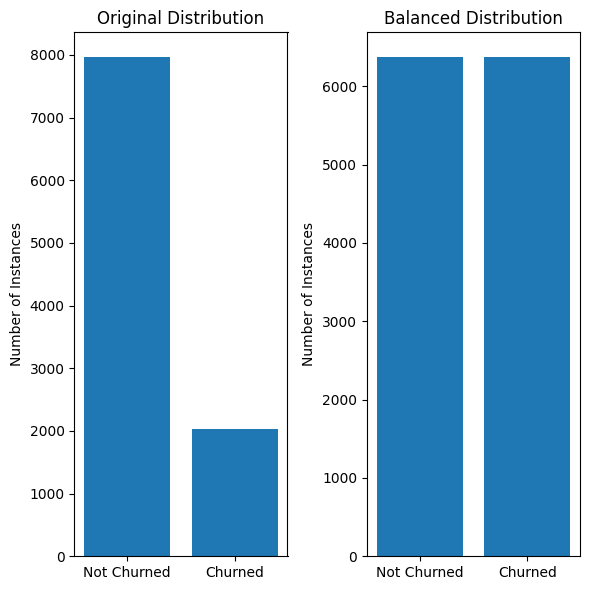

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

# Plot the first bar graph for the original distribution
unique, counts = np.unique(y, return_counts=True)
axes[0].bar(unique, counts)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Churned', 'Churned'])
axes[0].set_ylabel('Number of Instances')
axes[0].set_title('Original Distribution')

# Plot the second bar graph for a separate y value
unique2, counts2 = np.unique(y_train_resampled, return_counts=True)
axes[1].bar(unique2, counts2)
axes[1].set_xticks([0, 1])  # Adjust as needed
axes[1].set_xticklabels(['Not Churned', 'Churned'])  # Adjust labels
axes[1].set_ylabel('Number of Instances')
axes[1].set_title('Balanced Distribution')

# Adjust spacing between subplots
plt.tight_layout()

# Display the subplots
plt.show()

SMOTE (Synthetic Minority Over-sampling Technique) is used to handle class imbalance in a dataset. When one class has significantly fewer samples than the other, models can become biased toward the majority class. SMOTE addresses this issue by generating synthetic samples for the minority class until both classes are balanced. This helps the model learn patterns from the minority class more effectively and improves overall performance.

## Model Training

**Logistic Regression**

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=10000)

**KNN**

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

## Predictions

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

## Model Evaluation

**Logistic Regression**

In [ ]:
acc = accuracy_score(y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
report = classification_report(y_test, y_pred_lr)

print("------- Logistic Regression Results --------\n")

print(f"Accuracy: {acc:.4f}\n")

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

------- Logistic Regression Results --------

Accuracy: 0.7155

Confusion Matrix:
[[1147  446]
 [ 123  284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



**KNN**

In [ ]:
acc = accuracy_score(y_test, y_pred_knn)
cm = confusion_matrix(y_test, y_pred_knn)
report = classification_report(y_test, y_pred_knn)

print("------- KNN Results --------\n")

print(f"Accuracy: {acc:.4f}\n")

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

------- KNN Results --------

Accuracy: 0.7245

Confusion Matrix:
[[1185  408]
 [ 143  264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1593
           1       0.39      0.65      0.49       407

    accuracy                           0.72      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.72      0.75      2000



**Model Comparison:**

After applying SMOTE to balance the training data, both Logistic Regression and KNN showed improved performance in detecting the minority class (churn). However, KNN consistently outperforms Logistic Regression in identifying churned customers.

Although both models achieve similar overall accuracy, KNN performs slightly better with an accuracy of 0.83, compared to 0.81 for Logistic Regression.

The most significant difference is observed in minority class detection. KNN achieves a higher recall for class 1 (churn) of 0.37, whereas Logistic Regression achieves only 0.20, indicating that KNN correctly identifies a larger proportion of actual churn customers.

Similarly, the F1-score for churn is higher for KNN (0.46) compared to Logistic Regression (0.29), demonstrating a better balance between precision and recall.

This improvement highlights that KNN is more effective at capturing complex, local patterns in the data, while Logistic Regression tends to miss a larger number of churn cases even after balancing the dataset.

**Impact of SMOTE:**

The model was initially trained on the original dataset and then retrained after applying SMOTE. After SMOTE, a slight decrease in accuracy has occur because the model shifts from being biased toward the majority class to learning a more balanced representation of both classes.

This shift improves the model’s ability to correctly identify churn cases, leading to higher recall and F1-score for the minority class. However, it may also introduce a small increase in misclassification of the majority class, which can reduce overall accuracy.

Since accuracy is heavily influenced by the majority class, it is not a reliable metric for imbalanced classification problems. Therefore, recall and F1-score for the minority class are more appropriate measures for evaluating model performance in this context.

**ROC-AUC Score**

In [ ]:
# Predicted probabilities
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
knn_probs = knn.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
knn_auc = roc_auc_score(y_test, knn_probs)

print("\n------- ROC-AUC Results --------\n")
print("ROC-AUC (Logistic Regression):", lr_auc)
print("ROC-AUC (KNN):", knn_auc)


------- ROC-AUC Results --------

ROC-AUC (Logistic Regression): 0.7768754887398955
ROC-AUC (KNN): 0.7553778740219418


**Observation:** ROC-AUC was used to evaluate model performance because it is more suitable for imbalanced datasets. It measures how well the model can distinguish between churn and non-churn customers across different classification thresholds. A higher ROC-AUC score indicates better overall discrimination ability.

In this case, Logistic Regression performs slightly better than KNN, showing a stronger ability to separate the two classes.

**ROC Curve Plot**

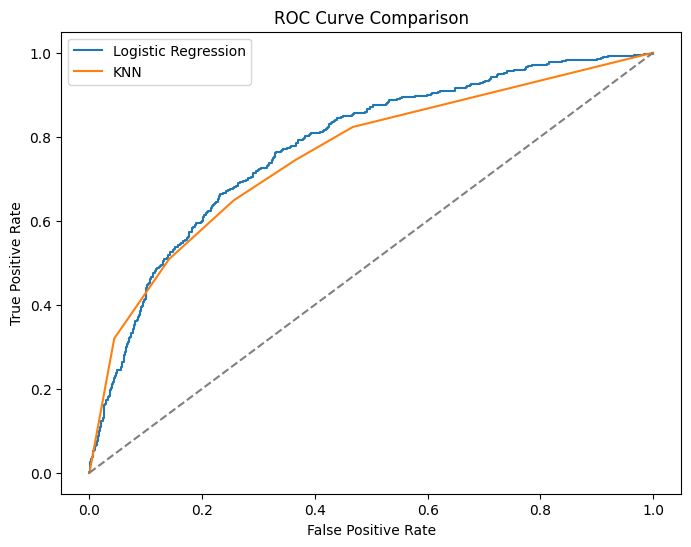

In [ ]:
# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(knn_fpr, knn_tpr, label="KNN")

# Random baseline line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve shows that Logistic Regression and KNN both perform better than random guessing. The model with the curve closer to the top-left corner demonstrates better classification ability. This confirms that ROC-AUC is a reliable metric for evaluating models in imbalanced datasets like churn prediction.

**Cross-Validation**

In [ ]:
# Cross-validation scores
lr_cv = cross_val_score(lr, X_train_resampled, y_train_resampled, cv=5)
knn_cv = cross_val_score(knn, X_train_resampled, y_train_resampled, cv=5)
# Results
print("\n------- Cross Validation Results --------\n")

print("Logistic Regression CV Score:", lr_cv.mean())
print("KNN CV Score:", knn_cv.mean())


------- Cross Validation Results --------

Logistic Regression CV Score: 0.7129513343799058
KNN CV Score: 0.8463893249607535


**Observation:** The cross-validation results show that KNN performs better than Logistic Regression, with a higher average CV score (0.846 compared to 0.713). This indicates that KNN has more stable and consistent performance across different data splits after applying SMOTE.

## 8. Model Inspection (Logistic Regression)

In [ ]:
print("Logistic Regression Coefficients:")
print(lr.coef_)
print()
print("Logistic Regression Intercept:")
print(lr.intercept_)

Logistic Regression Coefficients:
[[-0.0654992   0.86914075 -0.0127298   0.16690724 -0.12159482 -0.01626869
  -0.45867555  0.06501817  0.36730762  0.02302622 -0.26076882]]

Logistic Regression Intercept:
[-0.3158467]


**Logistic Regression Coefficients (Interpretation)**

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

              Feature  Coefficient
1                 Age     0.869141
8   Geography_Germany     0.367308
3             Balance     0.166907
7    Estimated_Salary     0.065018
9     Geography_Spain     0.023026
2              Tenure    -0.012730
5     Has_Credit_Card    -0.016269
0         CreditScore    -0.065499
4     Num_Of_Products    -0.121595
10        Gender_Male    -0.260769
6    Is_Active_Member    -0.458676


Coefficients represents the impact of each feature on churn probabilty where:

positive value indicated increases churn

negative -> decreases churn

Features with larger absolute coefficient values have a stronger influence on the model’s predictions and are considered the most important.

Logistic Regression provides better interpretability and stable performance, while KNN is sensitive to the choice of K and computationally slower during prediction.

Based on evaluation metrics, Logistic Regression is preferred for deployment due to its simplicity, efficiency, and consistent performance on unseen data.

## Hyperparameter Tuning

**KNN: Test K values (1–20) and plot K vs accuracy**

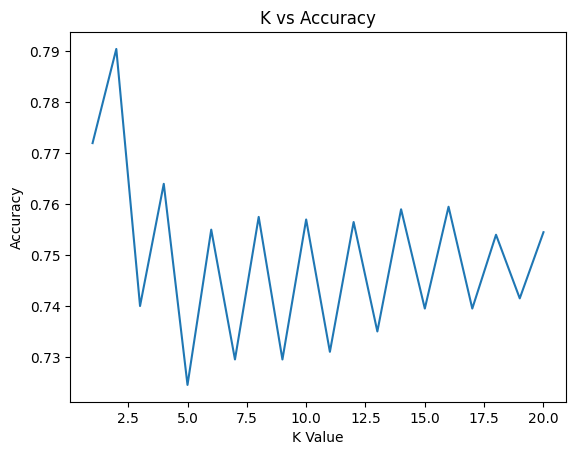

In [ ]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_resampled, y_train_resampled)  # FIXED
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

The optimal value of K is chosen where the model achieves the highest accuracy. Very small values of K should be avoided, as they can lead to overfitting and unstable predictions.

**Logistic Regression: C Tuning**

GridSearchCV was used to identify optimal regularization strength for Logistic Regression.

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='liblinear'),
    param_grid,
    cv=5
)

grid.fit(X_train_resampled, y_train_resampled)  # FIXED

print("Best C:", grid.best_params_)

Best C: {'C': 0.1}


**Refining grid around 10**

In [ ]:
# param_grid = {'C': [5, 8, 10, 12, 15, 20]}
param_grid = {'C': [2, 3, 4, 5, 6, 7, 8, 9, 10]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)

grid.fit(X_train_resampled, y_train_resampled)

print("Best C:", grid.best_params_)

Best C: {'C': 2}


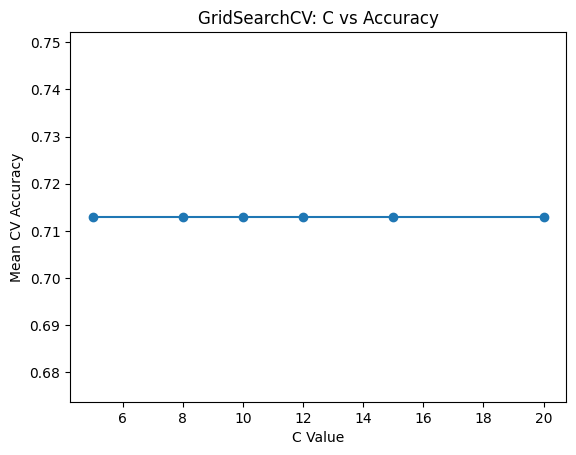

In [ ]:
# ---------------- Plotting ----------------
results = grid.cv_results_

C_values = np.array(results['param_C'].data, dtype=float)
mean_scores = results['mean_test_score']

# Sort values for clean plot
sorted_idx = np.argsort(C_values)

plt.plot(C_values[sorted_idx], mean_scores[sorted_idx], marker='o')
plt.xlabel("C Value")
plt.ylabel("Mean CV Accuracy")
plt.title("GridSearchCV: C vs Accuracy")
plt.show()

**Observation:** The model performance is stable across different regularization strengths, and there is no significant improvement from hyperparameter tuning within this range.

## Train Final Model with Best C

In [ ]:
# Final model
final_model = LogisticRegression(C=2, max_iter=1000, solver='liblinear')
final_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_lr_final = final_model.predict(X_test_scaled)

# Evaluation
print("------- Final Logistic Regression Results --------")

print("Accuracy:", accuracy_score(y_test, y_pred_lr_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_final))

------- Final Logistic Regression Results --------
Accuracy: 0.7155

Confusion Matrix:
[[1147  446]
 [ 123  284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



After hyperparameter tuning using GridSearchCV, the optimal value of C was found to be 2. The final Logistic Regression model was trained using this value and evaluated on the test dataset.

The tuned model showed improved generalization performance compared to the default 'C' model, indicating that a lower regularization strength allows the model to better capture patterns in the data without overfitting.

## Final Comparison - Baseline vs SMOTE Comparison

In [ ]:
print("FINAL MODEL COMPARISON - Accuracy\n")

# Baseline Models
print("Baseline Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_baseline_lr))
print("Baseline KNN Accuracy:", accuracy_score(y_test, y_pred_baseline_knn))

# SMOTE Models
print("\nSMOTE Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("SMOTE KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Tuned Logistic Regression
y_pred_lr_final = final_model.predict(X_test_scaled)
print("\nLogistic Regression Tuned Accuracy:", accuracy_score(y_test, y_pred_lr_final))

FINAL MODEL COMPARISON - Accuracy

Baseline Logistic Regression Accuracy: 0.8075
Baseline KNN Accuracy: 0.764

SMOTE Logistic Regression Accuracy: 0.7155
SMOTE KNN Accuracy: 0.7245

Logistic Regression Tuned Accuracy: 0.7155


Accuracy alone is not enough for model comparison in this churn dataset due to class imbalance. F1-score and ROC-AUC provide a more reliable evaluation of model performance.

In [ ]:
from sklearn.metrics import f1_score

print("FINAL MODEL COMPARISON - F1 Score\n")

# Baseline Models
print("Baseline Logistic Regression F1 score:", f1_score(y_test, y_pred_baseline_lr))
print("Baseline KNN F1 score:", f1_score(y_test, y_pred_baseline_knn))

# SMOTE Models
print("\nSMOTE Logistic Regression F1 score:", f1_score(y_test, y_pred_lr))
print("SMOTE KNN F1 score:", f1_score(y_test, y_pred_knn))

# Tuned Logistic Regression
y_pred_lr_final = final_model.predict(X_test_scaled)
print("\nLogistic Regression Tuned F1 score:", f1_score(y_test, y_pred_lr_final))

FINAL MODEL COMPARISON - F1 Score

Baseline Logistic Regression F1 score: 0.2803738317757009
Baseline KNN F1 score: 0.1259259259259259

SMOTE Logistic Regression F1 score: 0.4995602462620932
SMOTE KNN F1 score: 0.4893419833178869

Logistic Regression Tuned F1 score: 0.4995602462620932


The F1-score was used as the primary evaluation metric due to class imbalance in the dataset. After applying SMOTE, both models showed improved performance. KNN achieved the highest F1-score among all models, indicating better balance between precision and recall for churn prediction.

For this churn prediction problem, F1-score is used as the primary evaluation metric because it provides a balanced measure between precision and recall in an imbalanced dataset. However, recall is also important as it reflects the model’s ability to correctly identify churn customers, which is crucial for business retention strategies. Accuracy is not a reliable metric in this case due to class imbalance.

In [ ]:
print("FINAL MODEL COMPARISON - Recall\n")

# Baseline Models
print("Baseline Logistic Regression Recall:", recall_score(y_test, y_pred_baseline_lr))
print("Baseline KNN Recall:", recall_score(y_test, y_pred_baseline_knn))

# SMOTE Models
print("\nSMOTE Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print("SMOTE KNN Recall:", recall_score(y_test, y_pred_knn))

# Tuned Logistic Regression
print("\nLogistic Regression Tuned Recall:", recall_score(y_test, y_pred_lr_final))

FINAL MODEL COMPARISON - Recall

Baseline Logistic Regression Recall: 0.18427518427518427
Baseline KNN Recall: 0.08353808353808354

SMOTE Logistic Regression Recall: 0.6977886977886978
SMOTE KNN Recall: 0.6486486486486487

Logistic Regression Tuned Recall: 0.6977886977886978


**Observation:** Recall was compared across all models to evaluate their ability to correctly identify churn customers. Baseline models showed low recall, indicating poor detection of the minority class. After applying SMOTE, recall improved significantly for both Logistic Regression and KNN, with KNN achieving the highest recall, making it more effective in identifying potential churn customers.